#Predicting PICK3 (239 consequtive observations, up to 9/3/2025)

# Colab Book


In [2]:
!python --version


Python 3.12.11


In [1]:
pip install u8darts[torch]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.8/61.8 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.8/344.8 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
!pip install pandas

In [3]:
import darts
print(darts.__version__)

0.37.1


In [2]:
from google.colab import files
import pandas as pd

uploaded = files.upload()  # Pick your PICK3.csv from local machine
df = pd.read_csv("PICK3_239.csv")
df.columns = df.columns.str.strip()
print(df.head())

Saving PICK3_239.csv to PICK3_239.csv
   time  x1  x2  x3
0   239   1   6   3
1   238   0   4   8
2   237   7   2   3
3   236   4   5   2
4   235   3   6   3


In [32]:
print(df.tail())

     time  x1  x2  x3
234     5   7   6   7
235     4   0   0   6
236     3   5   4   6
237     2   9   0   6
238     1   9   7   7


# DARTS NBEATSModel MULTIVARIATE

In [ ]:
#Neural Basis Expansion Analysis Time Series Forecasting (N-BEATS)

In [19]:
# from darts import TimeSeries
# from darts.models import NBEATSModel
# import pandas as pd

# # Sample data
# data = pd.DataFrame(df)

# # Build time index
# # time_index = pd.date_range(start="2023-01-01", periods=len(data), freq="D")
# # data['time'] = time_index  # add time column

# # Create TimeSeries (multivariate)
# series = TimeSeries.from_dataframe(
#     data,
#     time_col="time",
#     value_cols=['x1', 'x2', 'x3'] )
# # Define & train model
# model = NBEATSModel(
#     input_chunk_length=238,
#     output_chunk_length=1,
#     n_epochs=8,
#     random_state=42
# )
# model.fit(series)

# # Forecast the next row
# forecast = model.predict(n=1)
# print("Next row prediction:")
# print(forecast.values())


In [20]:
import pandas as pd
from darts import TimeSeries
from darts.models import NBEATSModel
from darts.dataprocessing.transformers import Scaler

# data
data = df

# pretend time=239 is missing
train = data[data["time"] < 239]

series = TimeSeries.from_dataframe(train, time_col="time", value_cols=["x1","x2","x3"])

scaler = Scaler()
series_scaled = scaler.fit_transform(series)

# --- NO `verbose` here ---
model = NBEATSModel(
    input_chunk_length=3,
    output_chunk_length=1,
    n_epochs=100,
    random_state=42
)

model.fit(series_scaled)          # train
forecast = model.predict(n=1)     # predict 1 step ahead (time=239)
forecast = scaler.inverse_transform(forecast)

#print(forecast.to_pandas())

# get numpy array of values
###########print(forecast.values())

# # if to do DataFrame manually:
# import pandas as pd
# pred_df = pd.DataFrame(
#     forecast.values(),
#     index=forecast.time_index,    # time steps
#     columns=forecast.components   # variable names (x1, x2, x3)
# )
# print(pred_df)



INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 6.1 M  | train
-------------------------------------------------------------
6.1 M     Trainable params
1.3 K     Non-trainable params
6.1 M     Total params
24.309    Total estimated model params size (MB)
396       Modules in train mode
0         Modules in eval mode
/us

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

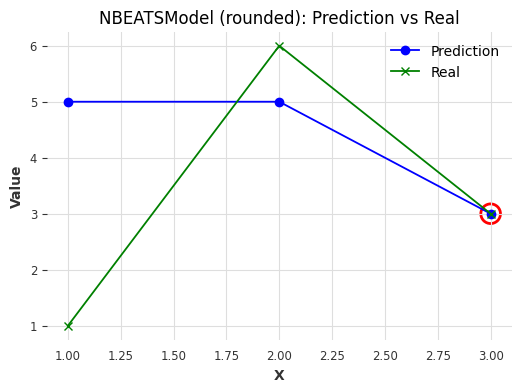

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Suppose forecast gives us 3 predicted values:
y_pred = forecast.values()[0]   # take the first row
x1_pred, x2_pred, x3_pred = y_pred
#forecast.values().flatten()   # shape (3,)
###################
Y_pred =[round(x1_pred),
                  round(x2_pred), round(x3_pred)]
#forecast.values().flatten()   # shape (3,)
#############
#Y_pred = np.round(Y_pred).astype(int)
X = np.array([1, 2, 3])
Y_true = np.array([1, 6, 3])           # your linear graph

plt.figure(figsize=(6,4))

# Plot prediction line
plt.plot(X, Y_pred, label="Prediction", marker="o", color="blue")

# Plot reference line
plt.plot(X, Y_true, label="Real", marker="x", color="green")

# # Check coincidences
# for x, yp, yt in zip(X, Y_pred, Y_true):
#     if np.isclose(yp, yt):  # if equal (can use tolerance if float)
#         plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)
# Highlight coincidences with red circles
for x, yp, yt in zip(X, Y_pred, Y_true):
    if yp == yt:
        plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)

plt.xlabel("X")
plt.ylabel("Value")
plt.legend()
plt.title("NBEATSModel (rounded): Prediction vs Real")
plt.show()

#DARTS RNN


# Recurrent Neural Network Model (RNNs).

# This class provides three variants of RNNs:

  #  Vanilla RNN ,  LSTM , GRU


# LSTM predition

In [25]:
import pandas as pd
from darts import TimeSeries
from darts.models import RNNModel
from darts.dataprocessing.transformers import Scaler

# -------------------------
# 1.  data
# -------------------------
# full 239-row DataFrame
data = df
# -------------------------
# 2. Sort ascending by time
# -------------------------
data = data.sort_values("time").reset_index(drop=True)

# -------------------------
# 3. Pretend row with time=239 is missing
# -------------------------
train = data[data["time"] < 239]

# -------------------------
# 4. Build TimeSeries object
# -------------------------
series = TimeSeries.from_dataframe(
    train,
    time_col="time",
    value_cols=["x1", "x2", "x3"]
)

# -------------------------
# 5. Scale (helps RNN training)
# -------------------------
scaler = Scaler()
series_scaled = scaler.fit_transform(series)

# -------------------------
# 6. Define RNN model
# -------------------------
# model = RNNModel(
#     model="LSTM",             # can be "RNN", "LSTM", or "GRU"
#     input_chunk_length=30,    # how many past time steps the RNN looks at
#     output_chunk_length=1,    # forecast 1 step ahead
#     hidden_dim=25,
#     n_rnn_layers=2,
#     dropout=0.1,
#     n_epochs=100,
#     random_state=42
# )

model = RNNModel(
    model="LSTM",
    input_chunk_length=10,   # must be ≤ 238
    output_chunk_length=1,
    hidden_dim=25,
    n_rnn_layers=2,
    dropout=0.1,
    n_epochs=300,
    random_state=42
)


# -------------------------
# 7. Fit
# -------------------------
model.fit(series_scaled)

# -------------------------
# 8. Forecast the next step (time=239)
# -------------------------
forecast_scaled = model.predict(n=1)
forecast = scaler.inverse_transform(forecast_scaled)

# -------------------------
# 9. Extract the 3 predicted numbers
# -------------------------
pred_values = forecast.values()[0]   # shape (3,)
x1_pred, x2_pred, x3_pred = pred_values

print(f"Predicted row for time=239:")
print(f"x1 = {x1_pred:.2f}, x2 = {x2_pred:.2f}, x3 = {x3_pred:.2f}")


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 8.2 K  | train
6 | V               | Linear           | 78     | train
-------------------------------------------------------------
8.3 K     Trainable params
0         Non-trainable params
8.3 K     Total params
0.033     Total estimated model params size (MB)
7         

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=300` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

Predicted row for time=239:
x1 = -0.56, x2 = 5.63, x3 = 1.70


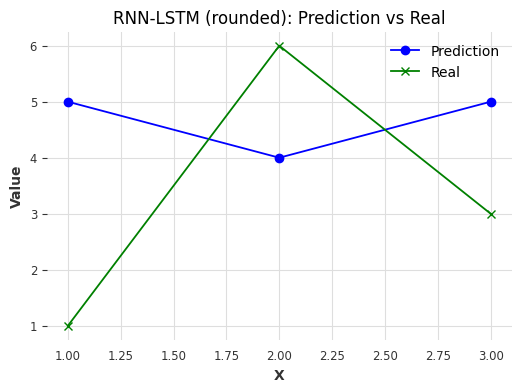

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Suppose forecast gives us 3 predicted values:
y_pred = forecast.values()[0]   # take the first row
x1_pred, x2_pred, x3_pred = y_pred
#forecast.values().flatten()   # shape (3,)
###################
Y_pred =[round(x1_pred),
                  round(x2_pred), round(x3_pred)]
#forecast.values().flatten()   # shape (3,)
#############
#Y_pred = np.round(Y_pred).astype(int)
X = np.array([1, 2, 3])
Y_true = np.array([1, 6, 3])           # your linear graph

plt.figure(figsize=(6,4))

# Plot prediction line
plt.plot(X, Y_pred, label="Prediction", marker="o", color="blue")

# Plot reference line
plt.plot(X, Y_true, label="Real", marker="x", color="green")

# # Check coincidences
# for x, yp, yt in zip(X, Y_pred, Y_true):
#     if np.isclose(yp, yt):  # if equal (can use tolerance if float)
#         plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)
# Highlight coincidences with red circles
for x, yp, yt in zip(X, Y_pred, Y_true):
    if yp == yt:
        plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)

plt.xlabel("X")
plt.ylabel("Value")
plt.legend()
plt.title("RNN-LSTM (rounded): Prediction vs Real")
plt.show()

# Vanilla RNN Prediction

In [ ]:
#Vanilla RNN Prediction

In [29]:
import pandas as pd
from darts import TimeSeries
from darts.models import RNNModel
from darts.dataprocessing.transformers import Scaler

# -------------------------
# 1. Example DataFrame
# -------------------------
# Replace these with your real 239-row data
data = pd.DataFrame({
    "time": [239,238,237,236,235] + list(range(234,0,-1)),  # just example ordering
    "x1": [1,0,7,4,3] + [0]*234,  # replace with your real x1
    "x2": [6,4,2,5,6] + [0]*234,  # replace with your real x2
    "x3": [3,8,3,2,3] + [0]*234   # replace with your real x3
})

# -------------------------
# 2. Sort ascending by time
# -------------------------
data = df

# -------------------------
# 3. Pretend time=239 is missing
# -------------------------
train_df = data[data["time"] < 239]

# -------------------------
# 4. Create TimeSeries object
# -------------------------
series = TimeSeries.from_dataframe(
    train_df,
    time_col="time",
    value_cols=["x1","x2","x3"]
)

# -------------------------
# 5. Scale (helps RNN training)
# -------------------------
scaler = Scaler()
series_scaled = scaler.fit_transform(series)

# -------------------------
# 6. Define Vanilla RNN model
# -------------------------
model = RNNModel(
    model="RNN",              # Vanilla RNN
    input_chunk_length=10,    # how many past steps to look at
    output_chunk_length=1,    # predict 1 step ahead
    hidden_dim=25,
    n_rnn_layers=1,           # single RNN layer
    dropout=0.1,
    n_epochs=100,
    random_state=42
)

# -------------------------
# 7. Fit model
# -------------------------
model.fit(series_scaled)

# -------------------------
# 8. Forecast next step (time=239)
# -------------------------
forecast_scaled = model.predict(n=1)
forecast = scaler.inverse_transform(forecast_scaled)

# -------------------------
# 9. Extract predicted numbers
# -------------------------
pred_values = forecast.values()[0]   # shape (3,)
x1_pred, x2_pred, x3_pred = pred_values

print(f"Predicted row for time=239:")
print(f"x1 = {x1_pred:.2f}, x2 = {x2_pred:.2f}, x3 = {x3_pred:.2f}")


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | RNN              | 750    | train
6 |

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

Predicted row for time=239:
x1 = 4.70, x2 = 3.79, x3 = 4.69


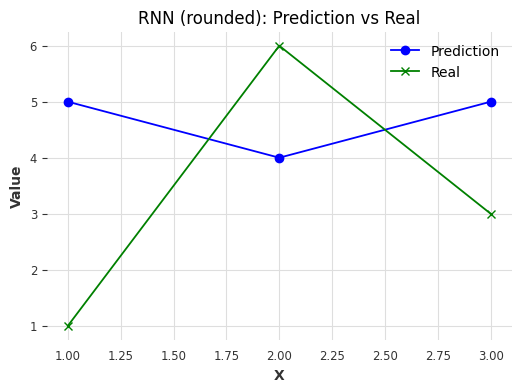

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Suppose forecast gives us 3 predicted values:
y_pred = forecast.values()[0]   # take the first row
x1_pred, x2_pred, x3_pred = y_pred
#forecast.values().flatten()   # shape (3,)
###################
Y_pred =[round(x1_pred),
                  round(x2_pred), round(x3_pred)]
#forecast.values().flatten()   # shape (3,)
#############
#Y_pred = np.round(Y_pred).astype(int)
X = np.array([1, 2, 3])
Y_true = np.array([1, 6, 3])           # your linear graph

plt.figure(figsize=(6,4))

# Plot prediction line
plt.plot(X, Y_pred, label="Prediction", marker="o", color="blue")

# Plot reference line
plt.plot(X, Y_true, label="Real", marker="x", color="green")

# # Check coincidences
# for x, yp, yt in zip(X, Y_pred, Y_true):
#     if np.isclose(yp, yt):  # if equal (can use tolerance if float)
#         plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)
# Highlight coincidences with red circles
for x, yp, yt in zip(X, Y_pred, Y_true):
    if yp == yt:
        plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)

plt.xlabel("X")
plt.ylabel("Value")
plt.legend()
plt.title("RNN (rounded): Prediction vs Real")
plt.show()

# GRU prediction

In [33]:
import pandas as pd
from darts import TimeSeries
from darts.models import RNNModel
from darts.dataprocessing.transformers import Scaler

# -------------------------
# 1. data
# -------------------------
# Replace the following with  real 239-row data
data = df

# -------------------------
# 2. Sort ascending by time
# -------------------------
data = data.sort_values("time").reset_index(drop=True)

# -------------------------
# 3. Pretend the last row (time=239) is missing
# -------------------------
train_df = data[data["time"] < 239]

# -------------------------
# 4. Create TimeSeries object
# -------------------------
series = TimeSeries.from_dataframe(
    train_df,
    time_col="time",
    value_cols=["x1","x2","x3"]
)

# -------------------------
# 5. Scale (recommended for RNN stability)
# -------------------------
scaler = Scaler()
series_scaled = scaler.fit_transform(series)

# -------------------------
# 6. Define GRU model
# -------------------------
model = RNNModel(
    model="GRU",               # GRU instead of Vanilla RNN
    input_chunk_length=10,     # number of past steps the model sees
    output_chunk_length=1,     # predict 1 step ahead
    hidden_dim=25,
    n_rnn_layers=2,
    dropout=0.1,
    n_epochs=300,
    random_state=42
)

# -------------------------
# 7. Train model
# -------------------------
model.fit(series_scaled)

# -------------------------
# 8. Forecast next step (time=239)
# -------------------------
forecast_scaled = model.predict(n=1)
forecast = scaler.inverse_transform(forecast_scaled)

# -------------------------
# 9. Extract predicted numbers
# -------------------------
pred_values = forecast.values()[0]   # shape (3,)
x1_pred, x2_pred, x3_pred = pred_values

print(f"Predicted row for time=239:")
print(f"x1 = {x1_pred:.2f}, x2 = {x2_pred:.2f}, x3 = {x3_pred:.2f}")


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | GRU              | 6.2 K  | train
6 | V               | Linear           | 78     | train
-------------------------------------------------------------
6.2 K     Trainable params
0         Non-trainable params
6.2 K     Total params
0.025     Total estimated model params size (MB)
7         

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=300` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

Predicted row for time=239:
x1 = 4.45, x2 = 3.07, x3 = 0.27


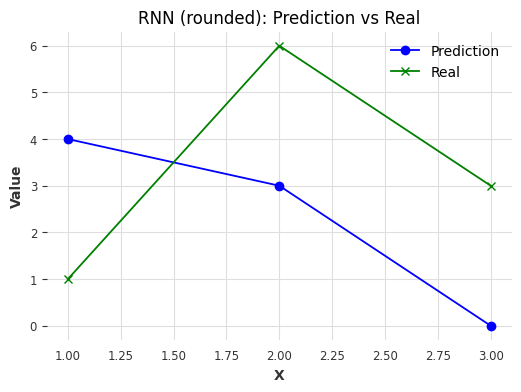

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Suppose forecast gives us 3 predicted values:
y_pred = forecast.values()[0]   # take the first row
x1_pred, x2_pred, x3_pred = y_pred
#forecast.values().flatten()   # shape (3,)
###################
Y_pred =[round(x1_pred),
                  round(x2_pred), round(x3_pred)]
#forecast.values().flatten()   # shape (3,)
#############
#Y_pred = np.round(Y_pred).astype(int)
X = np.array([1, 2, 3])
Y_true = np.array([1, 6, 3])           # your linear graph

plt.figure(figsize=(6,4))

# Plot prediction line
plt.plot(X, Y_pred, label="Prediction", marker="o", color="blue")

# Plot reference line
plt.plot(X, Y_true, label="Real", marker="x", color="green")

# # Check coincidences
# for x, yp, yt in zip(X, Y_pred, Y_true):
#     if np.isclose(yp, yt):  # if equal (can use tolerance if float)
#         plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)
# Highlight coincidences with red circles
for x, yp, yt in zip(X, Y_pred, Y_true):
    if yp == yt:
        plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)

plt.xlabel("X")
plt.ylabel("Value")
plt.legend()
plt.title("RNN (rounded): Prediction vs Real")
plt.show()

# Darts N-HiTS prediction

# N-HiTS is similar to N-BEATS (implemented in NBEATSModel), but attempts to provide better performance at lower computational cost by introducing multi-rate sampling of the inputs and multi-scale interpolation of the outputs.

In [5]:
import pandas as pd
from darts import TimeSeries
from darts.models import NHiTSModel
from darts.dataprocessing.transformers import Scaler

# -------------------------
# -------------------------
# Replace with real 239-row dataset
data = df

# -------------------------
# 2. Sort ascending by time
# -------------------------
data = data.sort_values("time").reset_index(drop=True)

# -------------------------
# 3. Pretend last row (time=239) is missing
# -------------------------
train_df = data[data["time"] < 239]

# -------------------------
# 4. Convert to TimeSeries
# -------------------------
series = TimeSeries.from_dataframe(
    train_df,
    time_col="time",
    value_cols=["x1","x2","x3"]
)

# -------------------------
# 5. Scale (recommended for deep models)
# -------------------------
scaler = Scaler()
series_scaled = scaler.fit_transform(series)

# -------------------------
# 6. Define N-HiTS model
# -------------------------
model = NHiTSModel(
    input_chunk_length=30,   # how many past steps the model uses
    output_chunk_length=1,   # predict 1 step ahead
    n_epochs=100,
    random_state=42
)

# -------------------------
# 7. Train model
# -------------------------
model.fit(series_scaled)

# -------------------------
# 8. Forecast next step (time=239)
# -------------------------
forecast_scaled = model.predict(n=1)
forecast = scaler.inverse_transform(forecast_scaled)

# -------------------------
# 9. Extract predicted numbers
# -------------------------
pred_values = forecast.values()[0]   # shape (3,)
x1_pred, x2_pred, x3_pred = pred_values

print(f"Predicted row for time=239:")
print(f"x1 = {x1_pred:.2f}, x2 = {x2_pred:.2f}, x3 = {x3_pred:.2f}")


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 997 K  | train
-------------------------------------------------------------
950 K     Trainable params
46.2 K    Non-trainable params
997 K     Total params
3.989     Total estimated model params size (MB)
42        Modules in train mode
0         Modules in eval mode
/us

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

Predicted row for time=239:
x1 = 2.44, x2 = 4.45, x3 = 4.75


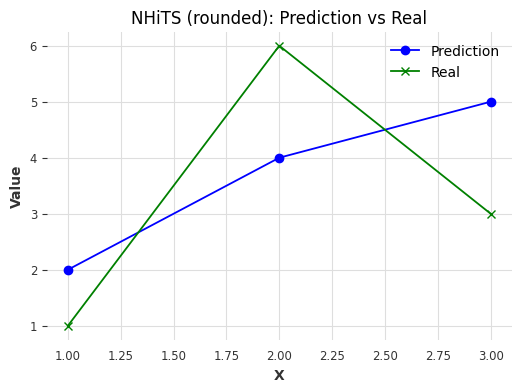

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Suppose forecast gives us 3 predicted values:
y_pred = forecast.values()[0]   # take the first row
x1_pred, x2_pred, x3_pred = y_pred
#forecast.values().flatten()   # shape (3,)
###################
Y_pred =[round(x1_pred),
                  round(x2_pred), round(x3_pred)]
#forecast.values().flatten()   # shape (3,)
#############
#Y_pred = np.round(Y_pred).astype(int)
X = np.array([1, 2, 3])
Y_true = np.array([1, 6, 3])           # your linear graph

plt.figure(figsize=(6,4))

# Plot prediction line
plt.plot(X, Y_pred, label="Prediction", marker="o", color="blue")

# Plot reference line
plt.plot(X, Y_true, label="Real", marker="x", color="green")

# # Check coincidences
# for x, yp, yt in zip(X, Y_pred, Y_true):
#     if np.isclose(yp, yt):  # if equal (can use tolerance if float)
#         plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)
# Highlight coincidences with red circles
for x, yp, yt in zip(X, Y_pred, Y_true):
    if yp == yt:
        plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)

plt.xlabel("X")
plt.ylabel("Value")
plt.legend()
plt.title("NHiTS (rounded): Prediction vs Real")
plt.show()

# Temporal Convolutional Network Model (TCN).


In [7]:
import pandas as pd
from darts import TimeSeries
from darts.models import TCNModel
from darts.dataprocessing.transformers import Scaler

# -------------------------
# 1.  real 239 rows
# -------------------------
data = df

# -------------------------
# 2. Sort ascending by time
# -------------------------
#data = data.sort_values("time").reset_index(drop=True)

# -------------------------
# 3. Pretend last row (time=239) is missing
# -------------------------
train_df = data[data["time"] < 239]

# -------------------------
# 4. Convert to TimeSeries
# -------------------------
series = TimeSeries.from_dataframe(
    train_df,
    time_col="time",
    value_cols=["x1", "x2", "x3"]
)

# -------------------------
# 5. Scale (recommended for deep models)
# -------------------------
scaler = Scaler()
series_scaled = scaler.fit_transform(series)

# -------------------------
# 6. Define TCN model
# -------------------------
model = TCNModel(
    input_chunk_length=30,   # number of past steps to use
    output_chunk_length=1,   # predict 1 step ahead
    n_epochs=100,
    random_state=42
)

# -------------------------
# 7. Train model
# -------------------------
model.fit(series_scaled)

# -------------------------
# 8. Forecast next step (time=239)
# -------------------------
forecast_scaled = model.predict(n=1)
forecast = scaler.inverse_transform(forecast_scaled)

# -------------------------
# 9. Extract predicted numbers
# -------------------------
pred_values = forecast.values()[0]   # shape (3,)
x1_pred, x2_pred, x3_pred = pred_values

print(f"Predicted row for time=239:")
print(f"x1 = {x1_pred:.2f}, x2 = {x2_pred:.2f}, x3 = {x3_pred:.2f}")


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | res_blocks      | ModuleList       | 240    | train
-------------------------------------------------------------
240       Trainable params
0         Non-trainable params
240       Total params
0.001     Total estimated model params size (MB)
26        Modules in train mode
0         Modules in eval mode
/us

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

Predicted row for time=239:
x1 = 2.18, x2 = 4.12, x3 = 5.80


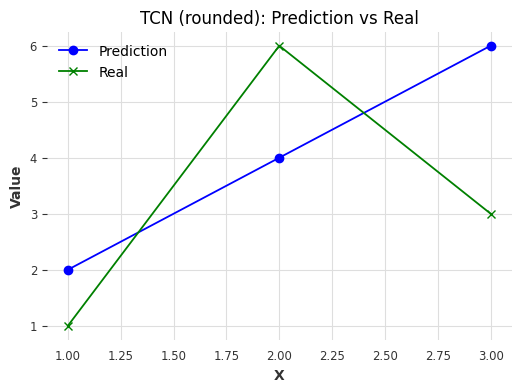

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Suppose forecast gives us 3 predicted values:
y_pred = forecast.values()[0]   # take the first row
x1_pred, x2_pred, x3_pred = y_pred
#forecast.values().flatten()   # shape (3,)
###################
Y_pred =[round(x1_pred),
                  round(x2_pred), round(x3_pred)]
#forecast.values().flatten()   # shape (3,)
#############
#Y_pred = np.round(Y_pred).astype(int)
X = np.array([1, 2, 3])
Y_true = np.array([1, 6, 3])           # your linear graph

plt.figure(figsize=(6,4))

# Plot prediction line
plt.plot(X, Y_pred, label="Prediction", marker="o", color="blue")

# Plot reference line
plt.plot(X, Y_true, label="Real", marker="x", color="green")

# # Check coincidences
# for x, yp, yt in zip(X, Y_pred, Y_true):
#     if np.isclose(yp, yt):  # if equal (can use tolerance if float)
#         plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)
# Highlight coincidences with red circles
for x, yp, yt in zip(X, Y_pred, Y_true):
    if yp == yt:
        plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)

plt.xlabel("X")
plt.ylabel("Value")
plt.legend()
plt.title("TCN (rounded): Prediction vs Real")
plt.show()

# Transformer Model

> Add blockquote



In [ ]:
#Transformer is a state-of-the-art deep learning model introduced in 2017.
# It is an encoder-decoder architecture whose core feature is the
# ‘multi-head attention’ mechanism, which is able to draw intra-dependencies
# within the input vector and within the output vector (‘self-attention’)
# as well as inter-dependencies between input and output vectors
#  (‘encoder-decoder attention’). The multi-head attention mechanism is
#  highly parallelizable, which makes the transformer architecture very
#  suitable to be trained with GPUs.

In [9]:
import pandas as pd
from darts import TimeSeries
from darts.models import TransformerModel
from darts.dataprocessing.transformers import Scaler

# -------------------------
# 1.  full 239 rows
# -------------------------
data = df

# -------------------------
# 2. Sort ascending by time
# -------------------------
#data = data.sort_values("time").reset_index(drop=True)

# -------------------------
# 3. Pretend last row (time=239) is missing
# -------------------------
train_df = data[data["time"] < 239]

# -------------------------
# 4. Convert to TimeSeries
# -------------------------
series = TimeSeries.from_dataframe(
    train_df,
    time_col="time",
    value_cols=["x1", "x2", "x3"]
)

# -------------------------
# 5. Scale (deep models benefit from scaling)
# -------------------------
scaler = Scaler()
series_scaled = scaler.fit_transform(series)

# -------------------------
# 6. Define Transformer Model
# -------------------------
model = TransformerModel(
    input_chunk_length=30,   # number of past steps the model looks at
    output_chunk_length=1,   # forecast 1 step ahead
    d_model=64,              # transformer hidden dimension
    nhead=4,                 # number of attention heads
    num_encoder_layers=2,
    num_decoder_layers=2,
    dim_feedforward=128,
    dropout=0.1,
    batch_size=16,
    n_epochs=100,
    random_state=42
)

# -------------------------
# 7. Train the model
# -------------------------
model.fit(series_scaled)

# -------------------------
# 8. Forecast next step (time=239)
# -------------------------
forecast_scaled = model.predict(n=1)
forecast = scaler.inverse_transform(forecast_scaled)

# -------------------------
# 9. Extract predicted values
# -------------------------
pred_values = forecast.values()[0]   # shape (3,)
x1_pred, x2_pred, x3_pred = pred_values

print(f"Predicted row for time=239:")
print(f"x1 = {x1_pred:.2f}, x2 = {x2_pred:.2f}, x3 = {x3_pred:.2f}")


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type                | Params | Mode 
--------------------------------------------------------------------
0 | criterion           | MSELoss             | 0      | train
1 | train_criterion     | MSELoss             | 0      | train
2 | val_criterion       | MSELoss             | 0      | train
3 | train_metrics       | MetricCollection    | 0      | train
4 | val_metrics         | MetricCollection    | 

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

Predicted row for time=239:
x1 = 4.15, x2 = 7.17, x3 = 2.70


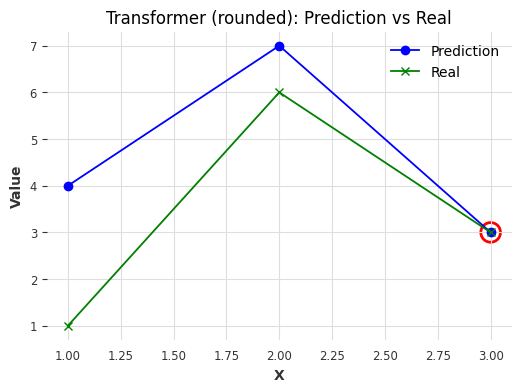

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Suppose forecast gives us 3 predicted values:
y_pred = forecast.values()[0]   # take the first row
x1_pred, x2_pred, x3_pred = y_pred
#forecast.values().flatten()   # shape (3,)
###################
Y_pred =[round(x1_pred),
                  round(x2_pred), round(x3_pred)]
#forecast.values().flatten()   # shape (3,)
#############
#Y_pred = np.round(Y_pred).astype(int)
X = np.array([1, 2, 3])
Y_true = np.array([1, 6, 3])           # your linear graph

plt.figure(figsize=(6,4))

# Plot prediction line
plt.plot(X, Y_pred, label="Prediction", marker="o", color="blue")

# Plot reference line
plt.plot(X, Y_true, label="Real", marker="x", color="green")

# # Check coincidences
# for x, yp, yt in zip(X, Y_pred, Y_true):
#     if np.isclose(yp, yt):  # if equal (can use tolerance if float)
#         plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)
# Highlight coincidences with red circles
for x, yp, yt in zip(X, Y_pred, Y_true):
    if yp == yt:
        plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)

plt.xlabel("X")
plt.ylabel("Value")
plt.legend()
plt.title("Transformer (rounded): Prediction vs Real")
plt.show()

# Temporal Fusion Transformers (TFT) for Interpretable Time Series Forecasting.

In [ ]:
#By default, this model uses the QuantileRegression likelihood, which means
#that its forecasts are probabilistic

In [12]:
import pandas as pd
from darts import TimeSeries
from darts.models import TFTModel
from darts.dataprocessing.transformers import Scaler

# -------------------------
# 1.  actual 239 rows
# -------------------------
data = df

# -------------------------
# 2. Sort ascending by time
# -------------------------
#data = data.sort_values("time").reset_index(drop=True)

# -------------------------
# 3. Pretend last row (time=239) is missing
# -------------------------
train_df = data[data["time"] < 239]

# -------------------------
# 4. Convert to Darts TimeSeries
# -------------------------
series = TimeSeries.from_dataframe(
    train_df,
    time_col="time",
    value_cols=["x1", "x2", "x3"]
)

# -------------------------
# 5. Scale the data (recommended for TFT)
# -------------------------
scaler = Scaler()
series_scaled = scaler.fit_transform(series)

# -------------------------
# 6. Define TFT Model
# -------------------------
# model = TFTModel(
#     input_chunk_length=30,   # past context
#     output_chunk_length=1,   # predict 1 step ahead
#     hidden_size=32,
#     lstm_layers=1,
#     num_attention_heads=4,
#     dropout=0.1,
#     batch_size=16,
#     n_epochs=100,
#     random_state=42
# )
model = TFTModel(
    input_chunk_length=30,
    output_chunk_length=1,
    hidden_size=32,
    lstm_layers=1,
    num_attention_heads=4,
    dropout=0.1,
    batch_size=16,
    n_epochs=100,
    add_relative_index=True,   # 👈 generates future covariates automatically
    random_state=42
)



# -------------------------
# 7. Train the model
# -------------------------
model.fit(series_scaled)

# -------------------------
# 8. Forecast next step (time=239)
# -------------------------
forecast_scaled = model.predict(n=1)
forecast = scaler.inverse_transform(forecast_scaled)

# -------------------------
# 9. Extract predicted values
# -------------------------
pred_values = forecast.values()[0]   # shape (3,)
x1_pred, x2_pred, x3_pred = pred_values

print(f"Predicted row for time=239:")
print(f"x1 = {x1_pred:.2f}, x2 = {x2_pred:.2f}, x3 = {x3_pred:.2f}")


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 3.9 K  | train
5  | decoder_vsn                       | _VariableSelectionNetwork   

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

Predicted row for time=239:
x1 = 9.65, x2 = 7.33, x3 = 0.37


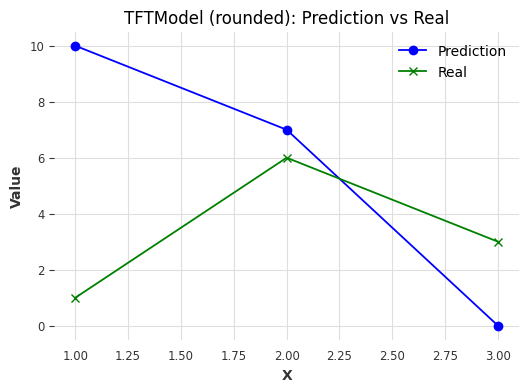

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Suppose forecast gives us 3 predicted values:
y_pred = forecast.values()[0]   # take the first row
x1_pred, x2_pred, x3_pred = y_pred
#forecast.values().flatten()   # shape (3,)
###################
Y_pred =[round(x1_pred),
                  round(x2_pred), round(x3_pred)]
#forecast.values().flatten()   # shape (3,)
#############
#Y_pred = np.round(Y_pred).astype(int)
X = np.array([1, 2, 3])
Y_true = np.array([1, 6, 3])           # your linear graph

plt.figure(figsize=(6,4))

# Plot prediction line
plt.plot(X, Y_pred, label="Prediction", marker="o", color="blue")

# Plot reference line
plt.plot(X, Y_true, label="Real", marker="x", color="green")

# # Check coincidences
# for x, yp, yt in zip(X, Y_pred, Y_true):
#     if np.isclose(yp, yt):  # if equal (can use tolerance if float)
#         plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)
# Highlight coincidences with red circles
for x, yp, yt in zip(X, Y_pred, Y_true):
    if yp == yt:
        plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)

plt.xlabel("X")
plt.ylabel("Value")
plt.legend()
plt.title("TFTModel (rounded): Prediction vs Real")
plt.show()

# Time-series Dense Encoder (TiDE)

In [ ]:
#TiDE is similar to Transformers (implemented in TransformerModel), but attempts
# to provide better performance at lower computational cost by introducing
# multilayer perceptron (MLP)-based encoder-decoders without attention.

In [15]:
import pandas as pd
from darts import TimeSeries
from darts.models import TiDEModel
from darts.dataprocessing.transformers import Scaler

# -------------------------
# 1.  actual 239 rows
# -------------------------
data = df


# -------------------------
# 2. Sort ascending by time
# -------------------------
#data = data.sort_values("time").reset_index(drop=True)

# -------------------------
# 3. Pretend last row (time=239) is missing
# -------------------------
train_df = data[data["time"] < 239]

# -------------------------
# 4. Convert to Darts TimeSeries
# -------------------------
series = TimeSeries.from_dataframe(
    train_df,
    time_col="time",
    value_cols=["x1", "x2", "x3"]
)

# -------------------------
# 5. Scale the series (recommended for deep models)
# -------------------------
scaler = Scaler()
series_scaled = scaler.fit_transform(series)

# -------------------------
# 6. Define TiDE model
# -------------------------
model = TiDEModel(
    input_chunk_length=30,   # past context length
    output_chunk_length=1,   # predict 1 step ahead
    hidden_size=64,
    num_encoder_layers=2,
    num_decoder_layers=2,
    dropout=0.1,
    batch_size=16,
    n_epochs=100,
    random_state=42
)

# -------------------------
# 7. Train the model
# -------------------------
model.fit(series_scaled)

# -------------------------
# 8. Forecast next step (time=239)
# -------------------------
forecast_scaled = model.predict(n=1)
forecast = scaler.inverse_transform(forecast_scaled)

# -------------------------
# 9. Extract predicted values
# -------------------------
pred_values = forecast.values()[0]   # shape (3,)
x1_pred, x2_pred, x3_pred = pred_values

print(f"Predicted row for time=239:")
print(f"x1 = {x1_pred:.2f}, x2 = {x2_pred:.2f}, x3 = {x3_pred:.2f}")


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name             | Type             | Params | Mode 
--------------------------------------------------------------
0 | criterion        | MSELoss          | 0      | train
1 | train_criterion  | MSELoss          | 0      | train
2 | val_criterion    | MSELoss          | 0      | train
3 | train_metrics    | MetricCollection | 0      | train
4 | val_metrics      | MetricCollection | 0      | train
5 | encoders         | Sequential       | 28.3 K | train
6 | decoders         | Sequential       | 18.7 K | train
7 | temporal_decoder | _ResidualBlock   | 694    | train
8 | lookback_skip    | Linear           | 31     | train
--------------------------------------------------------------
47.7 K    Traina

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

Predicted row for time=239:
x1 = 0.20, x2 = 1.84, x3 = 4.57


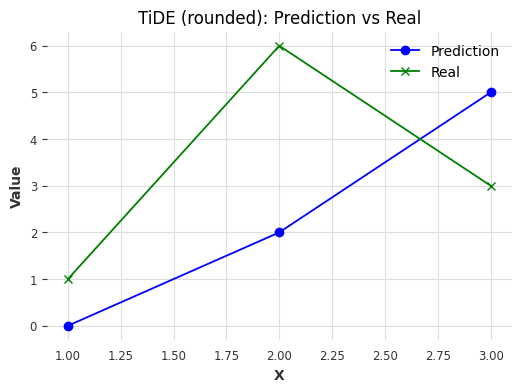

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Suppose forecast gives us 3 predicted values:
y_pred = forecast.values()[0]   # take the first row
x1_pred, x2_pred, x3_pred = y_pred
#forecast.values().flatten()   # shape (3,)
###################
Y_pred =[round(x1_pred),
                  round(x2_pred), round(x3_pred)]
#forecast.values().flatten()   # shape (3,)
#############
#Y_pred = np.round(Y_pred).astype(int)
X = np.array([1, 2, 3])
Y_true = np.array([1, 6, 3])           # your linear graph

plt.figure(figsize=(6,4))

# Plot prediction line
plt.plot(X, Y_pred, label="Prediction", marker="o", color="blue")

# Plot reference line
plt.plot(X, Y_true, label="Real", marker="x", color="green")

# # Check coincidences
# for x, yp, yt in zip(X, Y_pred, Y_true):
#     if np.isclose(yp, yt):  # if equal (can use tolerance if float)
#         plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)
# Highlight coincidences with red circles
for x, yp, yt in zip(X, Y_pred, Y_true):
    if yp == yt:
        plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)

plt.xlabel("X")
plt.ylabel("Value")
plt.legend()
plt.title("TiDE (rounded): Prediction vs Real")
plt.show()

#Time-Series Mixer (TSMixer)

In [ ]:
#Time-Series Mixer (TSMixer): An All-MLP Architecture for Time Series.

In [17]:
import pandas as pd
from darts import TimeSeries
from darts.models import TSMixerModel
from darts.dataprocessing.transformers import Scaler

# -------------------------
# 1. Example Data (replace with your actual 239 rows)
# -------------------------
data = df

# -------------------------
# 2. Sort ascending by time
# -------------------------
#data = data.sort_values("time").reset_index(drop=True)

# -------------------------
# 3. Pretend last row (time=239) is missing
# -------------------------
train_df = data[data["time"] < 239]

# -------------------------
# 4. Convert to Darts TimeSeries
# -------------------------
series = TimeSeries.from_dataframe(
    train_df,
    time_col="time",
    value_cols=["x1", "x2", "x3"]
)

# -------------------------
# 5. Scale the series (important for neural models)
# -------------------------
scaler = Scaler()
series_scaled = scaler.fit_transform(series)

# -------------------------
# 6. Define TSMixer Model
# -------------------------
model = TSMixerModel(
    input_chunk_length=30,   # how many past steps the model looks at
    output_chunk_length=1,   # predict 1 step ahead
    hidden_size=64,
    num_blocks=2,
    dropout=0.1,
    batch_size=16,
    n_epochs=100,
    random_state=42
)

# -------------------------
# 7. Train the model
# -------------------------
model.fit(series_scaled)

# -------------------------
# 8. Forecast next step (time=239)
# -------------------------
forecast_scaled = model.predict(n=1)
forecast = scaler.inverse_transform(forecast_scaled)

# -------------------------
# 9. Extract predicted values
# -------------------------
pred_values = forecast.values()[0]   # shape (3,)
x1_pred, x2_pred, x3_pred = pred_values

print(f"Predicted row for time=239:")
print(f"x1 = {x1_pred:.2f}, x2 = {x2_pred:.2f}, x3 = {x3_pred:.2f}")


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type             | Params | Mode 
-----------------------------------------------------------------
0 | criterion           | MSELoss          | 0      | train
1 | train_criterion     | MSELoss          | 0      | train
2 | val_criterion       | MSELoss          | 0      | train
3 | train_metrics       | MetricCollection | 0      | train
4 | val_metrics         | MetricCollection | 0      | train
5 | fc_hist             | Linear           | 31     | train
6 | feature_mixing_hist | _FeatureMixing   | 4.8 K  | train
7 | conditional_mixer   | ModuleList       | 17.2 K | train
8 | fc_out              | Linear           | 195    | train
----------------------------------------------

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

Predicted row for time=239:
x1 = 1.92, x2 = 5.63, x3 = 4.38


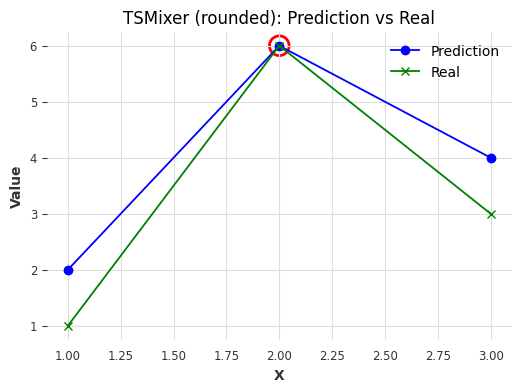

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Suppose forecast gives us 3 predicted values:
y_pred = forecast.values()[0]   # take the first row
x1_pred, x2_pred, x3_pred = y_pred
#forecast.values().flatten()   # shape (3,)
###################
Y_pred =[round(x1_pred),
                  round(x2_pred), round(x3_pred)]
#forecast.values().flatten()   # shape (3,)
#############
#Y_pred = np.round(Y_pred).astype(int)
X = np.array([1, 2, 3])
Y_true = np.array([1, 6, 3])           # your linear graph

plt.figure(figsize=(6,4))

# Plot prediction line
plt.plot(X, Y_pred, label="Prediction", marker="o", color="blue")

# Plot reference line
plt.plot(X, Y_true, label="Real", marker="x", color="green")

# # Check coincidences
# for x, yp, yt in zip(X, Y_pred, Y_true):
#     if np.isclose(yp, yt):  # if equal (can use tolerance if float)
#         plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)
# Highlight coincidences with red circles
for x, yp, yt in zip(X, Y_pred, Y_true):
    if yp == yt:
        plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)

plt.xlabel("X")
plt.ylabel("Value")
plt.legend()
plt.title("TSMixer (rounded): Prediction vs Real")
plt.show()

# XGBoost Models

In [19]:
import pandas as pd
from darts import TimeSeries
from darts.models import XGBModel
from darts.dataprocessing.transformers import Scaler

# -------------------------
# 1. r actual 239 rows
# -------------------------
data = df

# -------------------------
# 2. Sort ascending by time
# -------------------------
#data = data.sort_values("time").reset_index(drop=True)

# -------------------------
# 3. Pretend last row (time=239) is missing
# -------------------------
train_df = data[data["time"] < 239]

# -------------------------
# 4. Convert to Darts TimeSeries
# -------------------------
series = TimeSeries.from_dataframe(
    train_df,
    time_col="time",
    value_cols=["x1", "x2", "x3"]
)

# -------------------------
# 5. Scale (optional but helps tree models)
# -------------------------
scaler = Scaler()
series_scaled = scaler.fit_transform(series)

# -------------------------
# 6. Define XGB Model
# -------------------------
model = XGBModel(
    lags=30,            # use the past 30 time steps
    output_chunk_length=1,  # predict 1 step ahead
    n_estimators=300,
    random_state=42
)

# -------------------------
# 7. Train the model
# -------------------------
model.fit(series_scaled)

# -------------------------
# 8. Forecast next step (time=239)
# -------------------------
forecast_scaled = model.predict(n=1)
forecast = scaler.inverse_transform(forecast_scaled)

# -------------------------
# 9. Extract predicted values
# -------------------------
pred_values = forecast.values()[0]   # shape (3,)
x1_pred, x2_pred, x3_pred = pred_values

print(f"Predicted row for time=239:")
print(f"x1 = {x1_pred:.2f}, x2 = {x2_pred:.2f}, x3 = {x3_pred:.2f}")


Predicted row for time=239:
x1 = 2.68, x2 = 4.42, x3 = 8.00


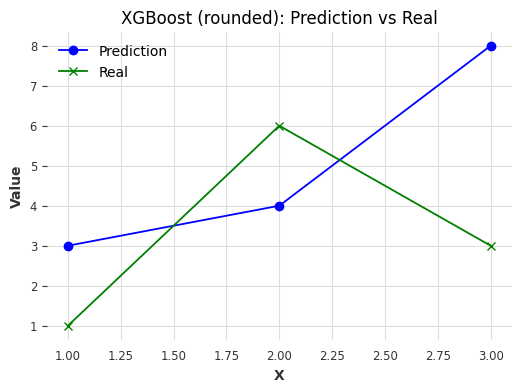

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Suppose forecast gives us 3 predicted values:
y_pred = forecast.values()[0]   # take the first row
x1_pred, x2_pred, x3_pred = y_pred
#forecast.values().flatten()   # shape (3,)
###################
Y_pred =[round(x1_pred),
                  round(x2_pred), round(x3_pred)]
#forecast.values().flatten()   # shape (3,)
#############
#Y_pred = np.round(Y_pred).astype(int)
X = np.array([1, 2, 3])
Y_true = np.array([1, 6, 3])           # your linear graph

plt.figure(figsize=(6,4))

# Plot prediction line
plt.plot(X, Y_pred, label="Prediction", marker="o", color="blue")

# Plot reference line
plt.plot(X, Y_true, label="Real", marker="x", color="green")

# # Check coincidences
# for x, yp, yt in zip(X, Y_pred, Y_true):
#     if np.isclose(yp, yt):  # if equal (can use tolerance if float)
#         plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)
# Highlight coincidences with red circles
for x, yp, yt in zip(X, Y_pred, Y_true):
    if yp == yt:
        plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)

plt.xlabel("X")
plt.ylabel("Value")
plt.legend()
plt.title("XGBoost (rounded): Prediction vs Real")
plt.show()

# Kalman Filter Forecaster¶

In [ ]:
#This model uses a Kalman filter to produce forecasts

In [21]:
import pandas as pd
from darts import TimeSeries
from darts.models import KalmanForecaster

# -------------------------
# 1.  actual 239 rows
# -------------------------
data = df

# -------------------------
# 2. Sort ascending by time
# -------------------------
#data = data.sort_values("time").reset_index(drop=True)

# -------------------------
# 3. Pretend last row (time=239) is missing
# -------------------------
train_df = data[data["time"] < 239]

# -------------------------
# 4. Convert to Darts TimeSeries
# -------------------------
series = TimeSeries.from_dataframe(
    train_df,
    time_col="time",
    value_cols=["x1", "x2", "x3"]
)

# -------------------------
# 5. Define Kalman Forecaster
# -------------------------
model = KalmanForecaster(dim_x=30)   # dim_x = latent state dimension (tuneable)

# -------------------------
# 6. Fit model
# -------------------------
model.fit(series)

# -------------------------
# 7. Forecast next step (time=239)
# -------------------------
forecast = model.predict(n=1)

# -------------------------
# 8. Extract predicted values
# -------------------------
pred_values = forecast.values()[0]   # shape (3,)
x1_pred, x2_pred, x3_pred = pred_values

print(f"Predicted row for time=239:")
print(f"x1 = {x1_pred:.2f}, x2 = {x2_pred:.2f}, x3 = {x3_pred:.2f}")


Predicted row for time=239:
x1 = 4.06, x2 = 4.36, x3 = 5.20


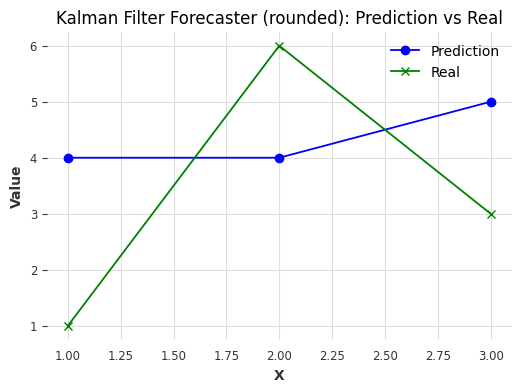

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Suppose forecast gives us 3 predicted values:
y_pred = forecast.values()[0]   # take the first row
x1_pred, x2_pred, x3_pred = y_pred
#forecast.values().flatten()   # shape (3,)
###################
Y_pred =[round(x1_pred),
                  round(x2_pred), round(x3_pred)]
#forecast.values().flatten()   # shape (3,)
#############
#Y_pred = np.round(Y_pred).astype(int)
X = np.array([1, 2, 3])
Y_true = np.array([1, 6, 3])           # your linear graph

plt.figure(figsize=(6,4))

# Plot prediction line
plt.plot(X, Y_pred, label="Prediction", marker="o", color="blue")

# Plot reference line
plt.plot(X, Y_true, label="Real", marker="x", color="green")

# # Check coincidences
# for x, yp, yt in zip(X, Y_pred, Y_true):
#     if np.isclose(yp, yt):  # if equal (can use tolerance if float)
#         plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)
# Highlight coincidences with red circles
for x, yp, yt in zip(X, Y_pred, Y_true):
    if yp == yt:
        plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)

plt.xlabel("X")
plt.ylabel("Value")
plt.legend()
plt.title("Kalman Filter Forecaster (rounded): Prediction vs Real")
plt.show()

# TBATS based on the Statsforecasts package.

Trigonometric Box-Cox transform, ARMA errors, Trend and Seasonal components (TBATS) model. It is an innovations state space model framework used for forecasting time series with multiple seasonalities. It uses a Box-Cox tranformation, ARMA errors, and a trigonometric representation of the seasonal patterns based on Fourier series.

In [15]:
import pandas as pd
from darts import TimeSeries
from darts.models import TBATS

# -------------------------
# 1. Example data (replace with your real 239 rows)
# -------------------------
data = df

# -------------------------
# 2. Remove the last row (time=239) for training
# -------------------------
train_df = data[data["time"] < 239]

# -------------------------
# 3. Train TBATS separately on each variable
# -------------------------
preds = {}
for col in ["x1", "x2", "x3"]:
    series = TimeSeries.from_dataframe(train_df, time_col="time", value_cols=col)
    #model = TBATS()          # TBATS auto-detects seasonality/trend
    model = TBATS(season_length=7)   # <-- REQUIRED
    model.fit(series)
    forecast = model.predict(n=1)
    preds[col] = forecast.values()[0][0]

# -------------------------
# 4. Combine predictions into one row
# -------------------------
pred_row = pd.DataFrame({
    "time": [239],
    "x1": [preds["x1"]],
    "x2": [preds["x2"]],
    "x3": [preds["x3"]],
})

print("Predicted row for time=239:")
print(pred_row)


/usr/local/lib/python3.12/dist-packages/statsforecast/tbats.py:949: UserWarning: Data contains zero or negative values, disabling Box-Cox transformation.
  warnings.warn(


Predicted row for time=239:
   time        x1        x2        x3
0   239  4.687007  4.808387  5.852624


/usr/local/lib/python3.12/dist-packages/statsforecast/tbats.py:949: UserWarning: Data contains zero or negative values, disabling Box-Cox transformation.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsforecast/tbats.py:949: UserWarning: Data contains zero or negative values, disabling Box-Cox transformation.
  warnings.warn(


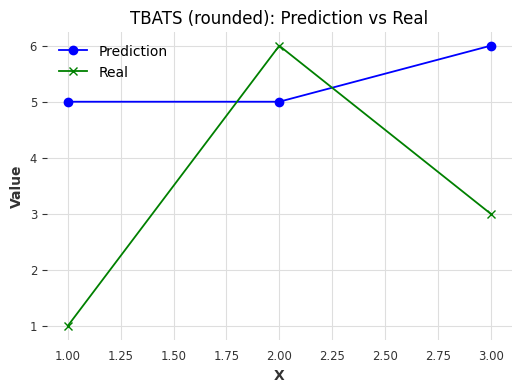

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Suppose forecast gives us 3 predicted values:
#y_pred = forecast.values()[0]   # take the first row
#x1_pred, x2_pred, x3_pred = y_pred
#forecast.values().flatten()   # shape (3,)
###################
Y_pred =[round(preds["x1"]),
                  round(preds["x2"]), round(preds["x3"])]
#forecast.values().flatten()   # shape (3,)
#############
#Y_pred = np.round(Y_pred).astype(int)
X = np.array([1, 2, 3])
Y_true = np.array([1, 6, 3])           # your linear graph

plt.figure(figsize=(6,4))

# Plot prediction line
plt.plot(X, Y_pred, label="Prediction", marker="o", color="blue")

# Plot reference line
plt.plot(X, Y_true, label="Real", marker="x", color="green")

# # Check coincidences
# for x, yp, yt in zip(X, Y_pred, Y_true):
#     if np.isclose(yp, yt):  # if equal (can use tolerance if float)
#         plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)
# Highlight coincidences with red circles
for x, yp, yt in zip(X, Y_pred, Y_true):
    if yp == yt:
        plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)

plt.xlabel("X")
plt.ylabel("Value")
plt.legend()
plt.title("TBATS (rounded): Prediction vs Real")
plt.show()

# Facebook Prophet

In [ ]:
#This class provides a basic wrapper around Facebook Prophet.
#It supports adding country holidays as well as custom seasonalities and
#adds support for stochastic forecasting and future covariates.

In [37]:
import pandas as pd
from darts import TimeSeries
from darts.models import Prophet

# -------------------------
# 1. Example data (replace with your real 239 rows)
# -------------------------
data = df

# -------------------------
# 2. Convert "time" to datetime
#    (treat each "time" step as a day, starting from 2000-01-01)
# -------------------------
n = 239

# Generate a daily datetime range starting at 2025-01-08
dates = pd.date_range(start="2025-01-08", periods=n, freq="D")
#data["time"] = pd.to_datetime(data["time"], origin="2025-01-08", unit="D")
#data["time"] = dates
data["time"] = dates[::-1]
# -------------------------
# 3. Remove the last row (time=239) for training
# -------------------------
train_df = data.iloc[:-1]   # all except last row

# -------------------------
# 4. Train Prophet separately for each variable
# -------------------------
preds = {}
for col in ["x1", "x2", "x3"]:
    series = TimeSeries.from_dataframe(train_df, time_col="time", value_cols=col)
    model = Prophet()
    model.fit(series)
    forecast = model.predict(n=1)
    preds[col] = forecast.values()[0][0]

# -------------------------
# 5. Combine predictions into one row
# -------------------------
pred_row = pd.DataFrame({
    "time": [data["time"].iloc[-1]],  # original time=239, now datetime
    "x1": [preds["x1"]],
    "x2": [preds["x2"]],
    "x3": [preds["x3"]],
})

print("Predicted row for time=239:")
print(pred_row)


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpr68mrqyb/2fl48fup.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpr68mrqyb/7cpjkpt5.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=80972', 'data', 'file=/tmp/tmpr68mrqyb/2fl48fup.json', 'init=/tmp/tmpr68mrqyb/7cpjkpt5.json', 'output', 'file=/tmp/tmpr68mrqyb/prophet_modelwdmisp2r/prophet_model-20250919021244.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
02:12:44 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
02:12:44 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Disabling yearly seasonalit

Predicted row for time=239:
        time        x1       x2        x3
0 2025-01-08  3.445524  4.21381  4.177763


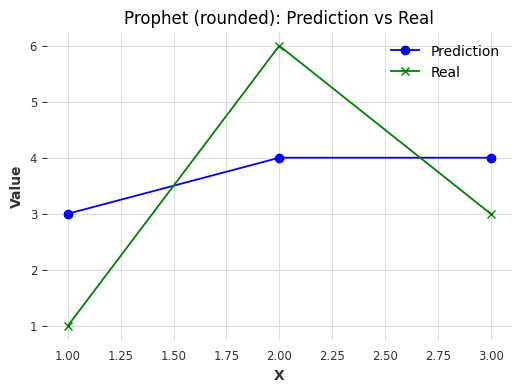

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Suppose forecast gives us 3 predicted values:
#y_pred = forecast.values()[0]   # take the first row
#x1_pred, x2_pred, x3_pred = y_pred
#forecast.values().flatten()   # shape (3,)
###################
Y_pred =[round(preds["x1"]),
                  round(preds["x2"]), round(preds["x3"])]
#forecast.values().flatten()   # shape (3,)
#############
#Y_pred = np.round(Y_pred).astype(int)
X = np.array([1, 2, 3])
Y_true = np.array([1, 6, 3])           # your linear graph

plt.figure(figsize=(6,4))

# Plot prediction line
plt.plot(X, Y_pred, label="Prediction", marker="o", color="blue")

# Plot reference line
plt.plot(X, Y_true, label="Real", marker="x", color="green")

# # Check coincidences
# for x, yp, yt in zip(X, Y_pred, Y_true):
#     if np.isclose(yp, yt):  # if equal (can use tolerance if float)
#         plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)
# Highlight coincidences with red circles
for x, yp, yt in zip(X, Y_pred, Y_true):
    if yp == yt:
        plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)

plt.xlabel("X")
plt.ylabel("Value")
plt.legend()
plt.title("Prophet (rounded): Prediction vs Real")
plt.show()

# StatsForecastModel

In [12]:
from google.colab import files
import pandas as pd

uploaded = files.upload()  # Pick your PICK3.csv from local machine
df = pd.read_csv("PICK3_239.csv")
df.columns = df.columns.str.strip()
print(df.head())

Saving PICK3_239.csv to PICK3_239 (1).csv
   time  x1  x2  x3
0   239   1   6   3
1   238   0   4   8
2   237   7   2   3
3   236   4   5   2
4   235   3   6   3


# StatsForecastModel in Darts is a wrapper around Nixtla’s statsforecast
library (ARIMA, ETS, Theta, etc.).
But  just like Prophet or TBATS, it is univariate only → so we must forecast x1, x2, and x3 separately and then combine.

In [23]:
import numpy as np
import pandas as pd
from darts import TimeSeries
from darts.models import StatsForecastModel
from statsforecast.models import AutoARIMA

# Suppose df looks like:
#    time   x1  x2  x3
# 0   239    1   6   3
# 1   238    0   4   8
# 2   237    7   2   3
# ...
# (239 rows)

# ---- Prepare data ----
# Convert "time" to a proper datetime index (descending → ascending)
df = df.sort_values("time")  # ensure ascending order
df["time"] = pd.date_range(start="2025-01-08", periods=len(df), freq="D")

# Create training series (drop last row = time 239)
series_all = TimeSeries.from_dataframe(df, time_col="time", value_cols=["x1", "x2", "x3"])
train_series = series_all[:-1]

# ---- Forecast each variable separately ----
preds = {}
for i, col in enumerate(["x1", "x2", "x3"]):
    print(f"Fitting AutoARIMA for {col}...")
    model = StatsForecastModel(model=AutoARIMA())
    model.fit(train_series.univariate_component(i))
    forecast = model.predict(n=1)              # one-step ahead
    # preds[col] = forecast.values().squeeze()   # numpy scalar
    #preds[col] = round(forecast.values().squeeze())   # ✅ round to 2 decimals
    value = forecast.values().squeeze()
    preds[col] = np.round(float(value))   # ✅ safe rounding
# ---- Assemble into a row ----
forecast_time = series_all.time_index[-1]     # the missing time = 239
forecast_df = pd.DataFrame([[forecast_time, preds["x1"], preds["x2"], preds["x3"]]],
                           columns=["time", "x1", "x2", "x3"])

print("Predicted row (time = 239):")
print(forecast_df)


Fitting AutoARIMA for x1...
Fitting AutoARIMA for x2...
Fitting AutoARIMA for x3...
Predicted row (time = 239):
        time   x1   x2   x3
0 2025-09-03  4.0  4.0  5.0


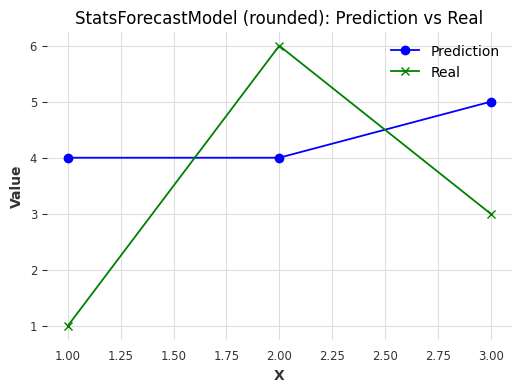

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Suppose forecast gives us 3 predicted values:
#y_pred = forecast.values()[0]   # take the first row
#x1_pred, x2_pred, x3_pred = y_pred
#forecast.values().flatten()   # shape (3,)
###################
Y_pred =[round(preds["x1"]),
                  round(preds["x2"]), round(preds["x3"])]
#forecast.values().flatten()   # shape (3,)
#############
#Y_pred = np.round(Y_pred).astype(int)
X = np.array([1, 2, 3])
Y_true = np.array([1, 6, 3])           # your linear graph

plt.figure(figsize=(6,4))

# Plot prediction line
plt.plot(X, Y_pred, label="Prediction", marker="o", color="blue")

# Plot reference line
plt.plot(X, Y_true, label="Real", marker="x", color="green")

# # Check coincidences
# for x, yp, yt in zip(X, Y_pred, Y_true):
#     if np.isclose(yp, yt):  # if equal (can use tolerance if float)
#         plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)
# Highlight coincidences with red circles
for x, yp, yt in zip(X, Y_pred, Y_true):
    if yp == yt:
        plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)

plt.xlabel("X")
plt.ylabel("Value")
plt.legend()
plt.title("StatsForecastModel (rounded): Prediction vs Real")
plt.show()